In [1]:
import os

for split in ["train", "val", "test"]:
    for cls in os.listdir(split):
        print(split, cls, len(os.listdir(f"{split}/{cls}")))


train fresh 1103
train moldy 705
val fresh 258
val moldy 188
test fresh 463
test moldy 259


In [4]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
    --------------------------------------- 6.0/332.0 MB 31.1 MB/s eta 0:00:11
   - -------------------------------------- 9.7/332.0 MB 23.1 MB/s eta


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True
)

val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    "train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_data = val_test_gen.flow_from_directory(
    "val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_data = val_test_gen.flow_from_directory(
    "test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 1808 images belonging to 2 classes.
Found 446 images belonging to 2 classes.
Found 722 images belonging to 2 classes.


In [7]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
output = Dense(1, activation="sigmoid")(x)

cnn_model = Model(base_model.input, output)

cnn_model.compile(
    optimizer=Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [8]:
history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
    
)


Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1045s 9s/step - accuracy: 0.5171 - loss: 0.7825 - val_accuracy: 0.5830 - val_loss: 0.7321
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 5049s 45s/step - accuracy: 0.6477 - loss: 0.6451 - val_accuracy: 0.6211 - val_loss: 0.6491
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1011s 9s/step - accuracy: 0.7174 - loss: 0.5612 - val_accuracy: 0.6502 - val_loss: 0.6083
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1052s 9s/step - accuracy: 0.7522 - loss: 0.5142 - val_accuracy: 0.6659 - val_loss: 0.5772
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 3256s 29s/step - accuracy: 0.7865 - loss: 0.4766 - val_accuracy: 0.7018 - val_loss: 0.5548
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1028s 9s/step - accuracy: 0.8070 - loss: 0.4448 - val_accuracy: 0.7152 - val_loss: 0.5366
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 6371s 57s/step - accuracy: 0.8225 - loss: 0.4257 - val_accuracy: 0.7332 - val_loss: 0.5204
Epoch 8/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1038s 9s/step - accuracy: 0.8186 - loss: 0.4084

In [10]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------ --------------------- 3.7/8.1 MB 18.0 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 19.1 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 17.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 17.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


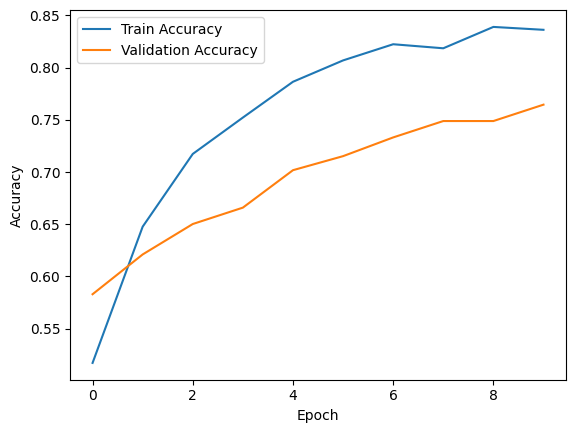

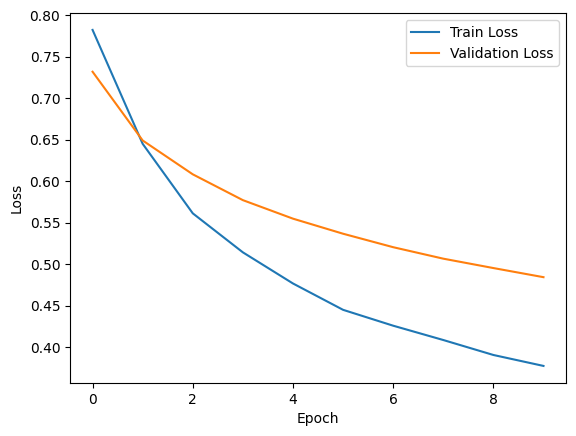

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

test_loss, test_acc = cnn_model.evaluate(test_data)

y_pred = (cnn_model.predict(test_data) > 0.5).astype(int)

print("CNN Test Accuracy:", test_acc)
print(confusion_matrix(test_data.classes, y_pred))
print(classification_report(test_data.classes, y_pred, target_names=["Fresh","Moldy"]))


46/46 ━━━━━━━━━━━━━━━━━━━━ 307s 7s/step - accuracy: 0.8144 - loss: 0.4139
46/46 ━━━━━━━━━━━━━━━━━━━━ 366s 8s/step
CNN Test Accuracy: 0.8144044280052185
[[375  88]
 [ 46 213]]
              precision    recall  f1-score   support

       Fresh       0.89      0.81      0.85       463
       Moldy       0.71      0.82      0.76       259

    accuracy                           0.81       722
   macro avg       0.80      0.82      0.80       722
weighted avg       0.83      0.81      0.82       722



: 